# *Laboratório I - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*
## Processamento Básico, Resoluções, Quantização
Atividade desenvolvida para obtenção de nota parcial da disciplina de PDI - 2026.1.


## Parte I: Manipulação de Imagens Digitais
Nessa primeira parte, fazemos dois exercícios: carregamento de uma imagem digital e exibição em tons de cinza; e obtenção do negativo da imagem.

##### Exercício 1

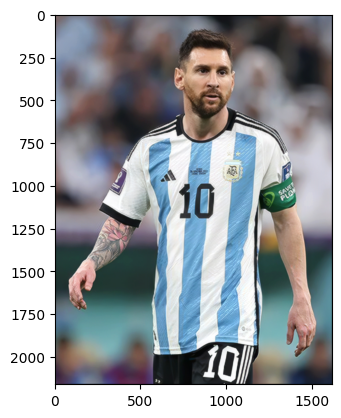

Shape: (2160, 1618, 3)
Tipo: uint8
Tamanho calculado: 3412.96875 KB
Tamanho medido: 1255.7421875 KB
Obs.: diferença dos tamanhos devido a compressão do JPG


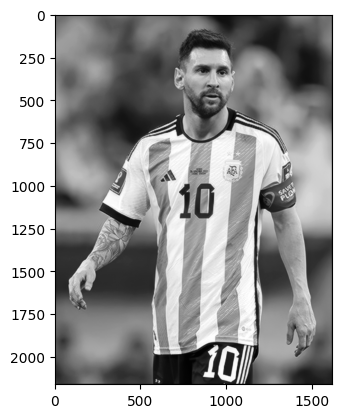

In [13]:
# importando libs
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os #para usar o getsize


PATH = "messi.jpg"
# lendo a imagem local
LOAD = cv2.imread(PATH) # lida em BGR em vez de RGB
IMAGE = cv2.cvtColor(LOAD, cv2.COLOR_BGR2RGB) # agora sim está em RGB

# plotando imagem original
plt.imshow(IMAGE)
plt.show() #para esconder o rótulo do objeto

# exibindo propriedades
print(f'Shape: {IMAGE.shape}') # aparece o 3 parâmetro pois eu loadei como imagem colorida RGB, se fosse RGBA seria 4 e se fosse tons de cinza seria nulo
print(f'Tipo: {IMAGE.dtype}')
print(f'Tamanho calculado: {1618*2160/1024} KB')
print(f'Tamanho medido: {os.path.getsize(PATH)/1024} KB')
print('Obs.: diferença dos tamanhos devido a compressão do JPG')

# plotando em tons de cinza
IMAGE_GRAY = cv2.cvtColor(LOAD, cv2.COLOR_BGR2GRAY) # precisa fazer essa transformação, pois caso contrário a imagem segue com 3 canais (colorida) e o cmap do plt seria ignorado
plt.imshow(IMAGE_GRAY, cmap='gray')
plt.show()



Comaparação  
Podemos perceber que existiu uma notável diferença entre o tamanho calculado e medido nessa imagem, enquanto que a imagem da monalisa não teve tanta diferença, isso ocorre devido ao tipo de compressão que essa imagem sofreu, enquanto que a monalisa não sofreu.  

Perguntas para reflexões  
*O que significam os valores de intensidade dos pixels em uma imagem em tons de cinza?*  
Em uma imagem em tons de cinza, os valores de intensidade dos pixels representam o nível de brilho de cada ponto da imagem. Valores baixos indicam regiões mais escuras, próximas do preto, enquanto valores altos indicam regiões mais claras, próximas do branco. Em geral, esses valores variam de 0 a 255 em imagens do tipo uint8.  

*Por que a imagem é representada em uint8? Como isso afeta a precisão e qualidade?*  
A imagem é representada em uint8 porque esse formato é simples, ocupa pouca memória e é suficiente para a maioria das aplicações de PDI, permitindo 256 níveis de intensidade. Isso torna o processamento mais rápido e eficiente. Porém, como há um número limitado de níveis, a precisão é menor do que em tipos como float32 ou uint16, o que pode causar perda de pequenas variações de intensidade. Ainda assim, o uint8 costuma oferecer boa qualidade visual na maioria dos casos.  

##### Exercício 2  

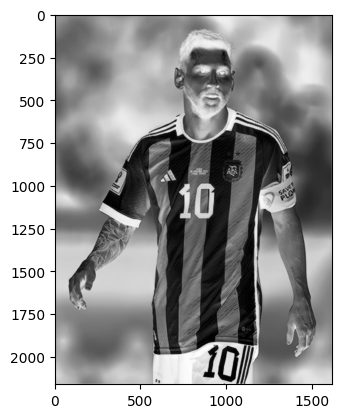

In [14]:
IMAGE_NEG = cv2.bitwise_not(IMAGE_GRAY)
# também poderia fazer 255−IMAGE, pois cada pixel teria seu valor subtraido para 255, ex.: branco é 255, após 255-255, ficaria 0, que é justamente preto, seu oposto
# esse bitwise trata de todos os bits realizando operações lógicas, nesse caso, um NOT faz a inversão do bit, que na prática é o mesmo que fazer 255-IMAGE, vai inverter a imagem para o negativo de toda forma
plt.imshow(IMAGE_NEG, cmap='gray')
plt.show()

Comparação  
É notável que a imagem do livro (figura 3.4) ficou com mais pixels brancos pois a imagem original (em tons de cinza) tinha muitos pixels pretos, enquanto isso, o messi ficou mais pixels pretos, porque tinha muitos pixels brancos.  

Pergunta para reflexão  
*O que acontece com os valores dos pixels quando criamos o negativo? Como isso altera a percep ̧c ̃ao visual?*  
Ao criar o negativo de uma imagem, os valores dos pixels são invertidos em relação à escala de intensidade. Em uma imagem uint8, isso geralmente é feito pela operação 255 - pixel, fazendo com que pixels claros se tornem escuros e pixels escuros se tornem claros. Assim, um valor próximo de 0 passa a ficar próximo de 255, e vice-versa. Visualmente, isso altera a percepção porque as regiões claras da imagem original aparecem escuras no negativo, e as escuras aparecem claras, produzindo uma inversão completa dos tons e destacando detalhes de forma diferente da imagem original.  

## Parte II: Quantização de imagens  
Nessa segunda parte, faremos quantização da imagem (em tons de cinza) com diferentes números de bits por pixel.  

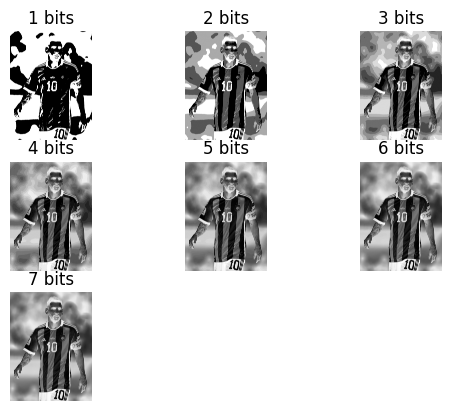

In [15]:
def quant(image, bits):
    levels = 2**bits # calcula quantos níveis de intensidade a imagem terá após a quantização
    step = 256 // levels # define o tamanho de cada faixa de valores (intervalo entre níveis)
    return (image // step).astype('uint8') # divide cada pixel pela faixa para agrupá-lo em um nível menor e mantém o tipo uint8

for bits in range(1, 8):
    IMAGE_REQ = quant(IMAGE_NEG, bits)
    ax = plt.subplot(3, 3, bits)
    ax.imshow(IMAGE_REQ, cmap="gray")
    ax.set_title(f'{bits} bits')
    ax.axis('off')

plt.subplots_adjust(wspace=0.2, hspace=0.2)
plt.show()

Comparação  
No exemplo do livro (figura 2.21) perdemos diversos detalhes da iamgem conforme fizemos a quantização, isso ocorreu devido a presença de muitos pixels com níveis de cinza com valores próximos. Enquanto isso, o messi não teve essa perca por se tratar de níveis de cinza com valores muitos distantes entre si

Perguntas para reflexão   
*Como a redução dos níveis de quantização impacta a qualidade visual?*  
A redução dos níveis de quantização diminui a quantidade de tons de cinza disponíveis para representar a imagem. Com isso, transições suaves entre regiões claras e escuras ficam mais “bruscas”, causando perda de detalhes e aparecimento de faixas visíveis entre tons, efeito conhecido como banding. Quanto menor o número de níveis, mais artificial e menos fiel a imagem tende a parecer.

*Qual é o nível mínimo de bits em que a imagem ainda é reconhecível sem muita perda de detalhes?*   
Isso depende do conteúdo da imagem, mas em geral imagens em 6 ou 5 bits (64 ou 32 níveis de cinza) ainda costumam ser bem reconhecíveis, com perda moderada de detalhes. Abaixo disso, como em 4 bits (16 níveis), a imagem normalmente ainda pode ser identificada, mas a perda visual já se torna mais perceptível. Portanto, de forma geral, entre 5 e 6 bits costuma ser um bom limite mínimo para manter a imagem reconhecível sem muita perda de detalhes.
 
## Parte II: Compressão e qualidade Visual  
Nessa parte faremos a compressão da imagem em JPEG para avaliarmos o nível de compressão em relação a imagem original, nesse caso, em JPG (que já tem compressão também). Faremos também para a imagem quantizada.


Tamanho original: 1255.7421875 KB
Tamanho original com compressão em JPEG (95%): 606.265625 KB
Tamanho original com compressão em JPEG (50%): 171.205078125 KB


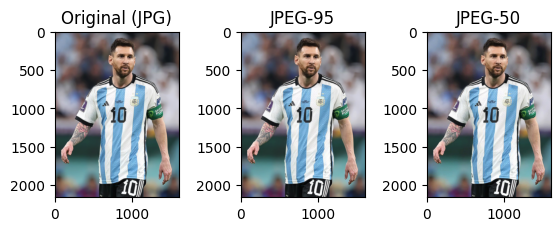

In [16]:
print(f'Tamanho original: {os.path.getsize(PATH)/1024} KB') #printando o valor do tamanho medido da imagem original

TEMP1 = cv2.imread(PATH) # loadando a imagem original

cv2.imwrite("messi-95.jpeg", TEMP1, [cv2.IMWRITE_JPEG_QUALITY, 95]) #fazendo a conversão para  JPEG em 95%
print(f'Tamanho original com compressão em JPEG (95%): {os.path.getsize("messi-95.jpeg")/1024} KB')
cv2.imwrite("messi-50.jpeg", TEMP1, [cv2.IMWRITE_JPEG_QUALITY, 50]) #fazendo a conversão para JPEG em 50%
print(f'Tamanho original com compressão em JPEG (50%): {os.path.getsize("messi-50.jpeg")/1024} KB')


#printando as imagens citadas
plt.subplot(1,3,1)
plt.title('Original (JPG)')
plt.imshow(IMAGE, cmap='gray')

plt.subplot(1,3,2)
IMAGE_95 = cv2.imread("messi-95.jpeg")
plt.title('JPEG-95')
plt.imshow(cv2.cvtColor(IMAGE_95, cv2.COLOR_BGR2RGB))

plt.subplot(1,3,3)
IMAGE_50 = cv2.imread("messi-50.jpeg")
plt.title('JPEG-50')
plt.imshow(cv2.cvtColor(IMAGE_50, cv2.COLOR_BGR2RGB))
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()


Comparação  
Conforme observado, o arquivo em JPEG foi considerávelmente menor em tamanho em relação ao arquivo original devido a compressão realizada.  

Perguntas  
*Como a compressão JPEG afeta a qualidade visual? Quais detalhes são mais afetados?*  
A compressão JPEG reduz o tamanho do arquivo com perda de informação, o que pode diminuir a qualidade visual da imagem. Em níveis mais altos de compressão, a imagem pode ficar menos nítida, com borramentos e aparecimento de artefatos, como blocos ou distorções em certas regiões. Os detalhes mais afetados costumam ser as bordas finas, texturas, pequenos padrões e transições suaves, pois são áreas que exigem mais informação para serem representadas com fidelidade.

*A qualidade de compressão a 50% ainda é aceitável? Em que situações pode ser usada?*  
Em muitos casos, a compressão JPEG em 50% ainda pode ser considerada aceitável, principalmente quando o objetivo é reduzir bastante o tamanho do arquivo sem exigir alta fidelidade visual. Ela pode ser usada em imagens para web, pré-visualizações, compartilhamento rápido, documentos informais ou aplicações em que economia de espaço e velocidade de transmissão são mais importantes que a preservação total dos detalhes. Porém, para imagens que exigem alta qualidade, como análise detalhada, impressão ou processamento posterior, essa taxa pode causar perda visível demais.  


## Parte IV: Resolução de intensidade e espacial  

Nessa parte, faremos 2 exercícios: reduzir a resolução de intensidade e reduzir a resolução espacial.

#### Exercício 1


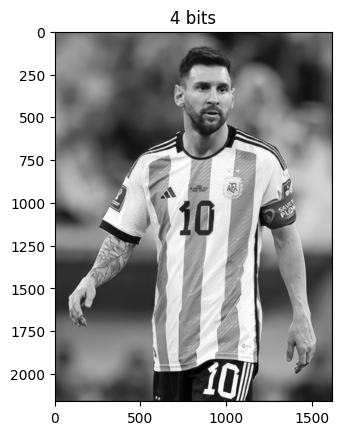

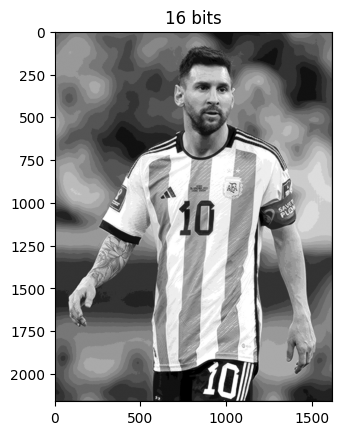

In [17]:
IMAGE_256N = quant(IMAGE_GRAY,8)
plt.title('4 bits')
plt.imshow(IMAGE_256N,cmap='gray')
plt.show()

IMAGE_16N = quant(IMAGE_GRAY,4)
plt.title('16 bits')
plt.imshow(IMAGE_16N, cmap='gray')
plt.show()

Comparação  
Em tons de cinza fica muito claro a diferença de ter uma grande variação de intensidade para uma pequena variação, pois nessa segunda, surge algumas manchas na imagem, impedindo a percepção de certos detalhes.  

Perguntas para reflexão  
*Qual é o impacto da redução de níveis de intensidade na suavidade dos gradientes?*  
A redução dos níveis de intensidade diminui a quantidade de tons disponíveis para representar variações de brilho, o que faz com que os gradientes fiquem menos suaves e mais “quebrados”. Em vez de uma transição contínua entre tons, passam a surgir mudanças bruscas entre faixas de intensidade, causando perda de suavidade e o aparecimento de bandas visíveis na imagem.

*Qual a importância de manter alta resolução de intensidade em imagens médicas?*  
Manter alta resolução de intensidade em imagens médicas é muito importante porque pequenas variações de brilho podem representar diferenças sutis entre tecidos, estruturas ou possíveis alterações patológicas. Se a resolução de intensidade for baixa, esses detalhes podem se perder, dificultando a interpretação e prejudicando a precisão do diagnóstico.  

*O que é intervalo dinâmico ou dynamic range?*  
O intervalo dinâmico é a faixa de valores de intensidade que uma imagem pode representar, ou seja, a diferença entre o menor e o maior valor possível de brilho. Em uma imagem uint8, por exemplo, o intervalo dinâmico vai de 0 a 255. Quanto maior o intervalo dinâmico, maior a capacidade de representar variações sutis entre regiões escuras e claras da imagem.

#### Exercício 2

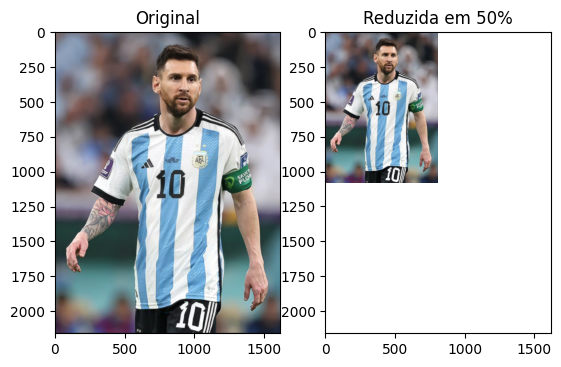

In [18]:
plt.subplot(1,2,1)
plt.title('Original')
plt.imshow(IMAGE)

IMAGE_RESIZED = cv2.resize(IMAGE,None,fx=0.5, fy=0.5) #o none é para não atribuir valor final manualmente
plt.subplot(1,2,2)
plt.title('Reduzida em 50%')
plt.imshow(IMAGE_RESIZED)
plt.xlim(0, IMAGE.shape[1])  # mantém escala da original
plt.ylim(IMAGE.shape[0], 0)
plt.show()

Comparação  
Conforme visto acima, é nítido a diferença de tamanho sofrida devido a redução espacial.

Perguntas para reflexão  
*Como a redução da resolução espacial afeta a capacidade de identificar detalhes?*  
A redução da resolução espacial diminui a quantidade de pixels usados para representar a imagem, o que causa perda de detalhes finos e menor nitidez. Com menos pixels, estruturas pequenas podem desaparecer, bordas ficam menos definidas e a imagem pode parecer borrada ou pixelada, dificultando a identificação precisa de objetos ou regiões importantes.  
  
*Qual seria a resolução mínima aceitável para diagnósticos médicos ou impressão?*   
A resolução mínima aceitável depende da aplicação, mas, em geral, para diagnósticos médicos é necessário manter uma resolução alta, pois pequenos detalhes podem ser essenciais para a análise, então resoluções baixas não são adequadas. Já para impressão, costuma-se considerar aceitável uma resolução em torno de 300 dpi, pois isso garante boa qualidade visual e preservação dos detalhes. Em ambos os casos, a resolução mínima deve ser suficiente para não comprometer a interpretação ou a visualização da imagem.  

## Parte V: Conectividade e adjacência  
Nessa parte faremos a implementação de algoritmo para analisar conectividade 4 e 8 em imagens bińarias; e aplicaremos conceitos de conectividade para análise de objetos em imagens.

#### Exercício 1

Para analisar conectividade 4 e 8 em imagens binárias, podemos implementar um algoritmo de rotulagem de componentes conexos (Connected Components) usando BFS/DFS.


Objetos (4-conectividade): 311
Objetos (8-conectividade): 257


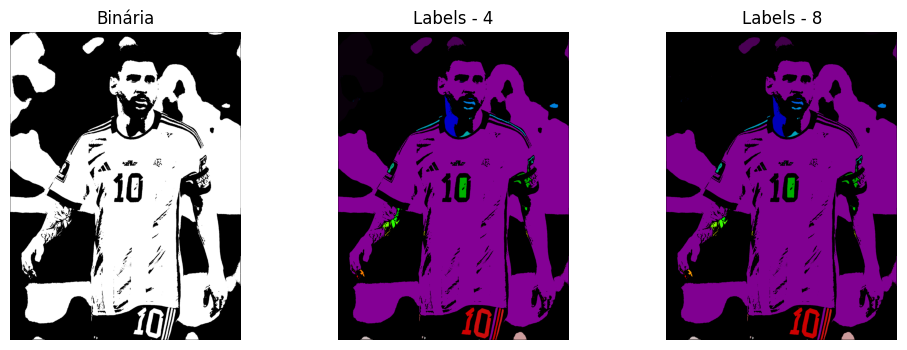

In [19]:
# binariza
_, bin_img = cv2.threshold(IMAGE_GRAY, 127, 255, cv2.THRESH_BINARY)

# conectividade 4
num_labels4, labels4 = cv2.connectedComponents(bin_img, connectivity=4)

# conectividade 8
num_labels8, labels8 = cv2.connectedComponents(bin_img, connectivity=8)

print("Objetos (4-conectividade):", num_labels4 - 1)  # tira o fundo
print("Objetos (8-conectividade):", num_labels8 - 1)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(bin_img, cmap='gray')
plt.title("Binária")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(labels4, cmap='nipy_spectral')
plt.title("Labels - 4")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(labels8, cmap='nipy_spectral')
plt.title("Labels - 8")
plt.axis("off")

plt.show()

Conceitos:  
*O que  ́e conectividade 4-adjacente e 8-adjacente?*  
Em imagens binárias, a conectividade define quais pixels vizinhos são considerados ligados entre si. Na conectividade 4-adjacente, um pixel é considerado conectado apenas aos seus vizinhos nas direções cima, baixo, esquerda e direita. Já na conectividade 8-adjacente, além desses quatro, também são considerados conectados os vizinhos nas diagonais, totalizando oito vizinhos possíveis.  

*Como identificar componentes conectados em imagens binarias?*  
Os componentes conectados são grupos de pixels com valor 1 (ou branco) que estão ligados entre si segundo um critério de conectividade, como 4 ou 8. Para identificá-los, percorre-se a imagem procurando pixels ativos e, quando um é encontrado, todos os pixels conectados a ele são agrupados e recebem o mesmo rótulo. Esse processo pode ser feito com algoritmos de rotulagem de componentes conectados, como flood fill, busca em largura (BFS) ou busca em profundidade (DFS).  

*Qual a diferen ̧ca pr ́atica entre usar conectividade 4 vs 8?*  
Na prática, a conectividade 4 é mais restritiva, pois considera apenas vizinhos horizontais e verticais, podendo separar regiões que se tocam apenas pelas diagonais. Já a conectividade 8 é mais permissiva, unindo também pixels conectados diagonalmente, o que geralmente resulta em menos componentes separados. Assim, usar 4 ou 8 pode mudar diretamente a segmentação da imagem e a quantidade de objetos detectados.  

#### Exercício 2  

A conectividade é usada em PDI para identificar, separar e analisar objetos em imagens, principalmente binárias. Após a segmentação, os pixels que pertencem ao objeto são agrupados conforme sua relação de vizinhança. Na conectividade-4, um pixel é considerado conectado apenas aos vizinhos acima, abaixo, à esquerda e à direita; já na conectividade-8, também são considerados os vizinhos diagonais.  

Na prática, isso permite realizar a rotulagem de componentes conexos, em que cada conjunto de pixels conectados recebe um rótulo único, representando um objeto distinto na imagem. Assim, é possível contar quantos objetos existem, separá-los individualmente e extrair características como área, perímetro, posição, forma e centróide.  
 
A escolha entre conectividade-4 e 8 influencia diretamente a análise: com 4-conectividade, objetos tocando apenas pelas diagonais tendem a ser considerados separados; com 8-conectividade, esses mesmos objetos podem ser interpretados como um único componente. Portanto, a conectividade é um conceito fundamental para garantir uma interpretação coerente da estrutura dos objetos presentes na imagem.  
  

Perguntas para reflexão
*Por que a conectividade é fundamental em análise de imagens médicas?*  
A conectividade é fundamental em imagens médicas porque ela permite identificar e separar corretamente estruturas anatômicas, tecidos ou possíveis lesões com base na ligação entre pixels vizinhos. Isso é importante para segmentação, medição de áreas, contagem de regiões e análise de formas, ajudando a localizar e interpretar estruturas de interesse com maior precisão.

*Como a escolha entre conectividade 4 ou 8 afeta a contagem de objetos?*  
A escolha entre conectividade 4 ou 8 pode alterar diretamente a contagem de objetos em uma imagem binária. Com a conectividade 4, pixels ligados apenas pelas diagonais não são considerados conectados, o que pode fazer com que uma mesma região seja dividida em vários objetos. Já com a conectividade 8, conexões diagonais também são aceitas, o que tende a unir mais pixels em um mesmo componente e, portanto, geralmente resulta em uma contagem menor de objetos.

*Quais aplicações práticas usam análise de conectividade?*  
A análise de conectividade é usada em diversas aplicações práticas, como segmentação de tumores e órgãos em imagens médicas, contagem de células em microscopia, detecção de objetos em visão computacional, reconhecimento de caracteres em OCR, inspeção industrial para identificar falhas e análise de partículas em imagens científicas.

## Parte VI: Impacto dos Sensores na Qualidade

Nessa parte iremos adicionar ruído para simular sensores de baixa qualidade.

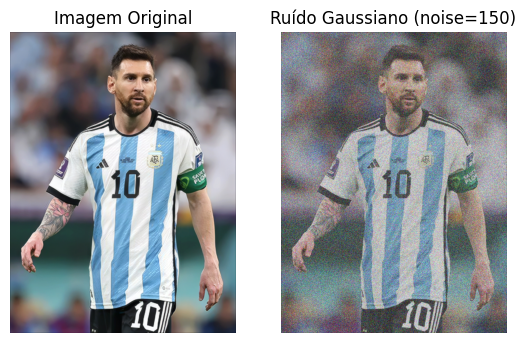

In [ ]:
NOISE = 150 # def do nível de ruído
NOISY_IMAGE = np.clip(IMAGE + np.random.normal(0, NOISE, IMAGE.shape), 0, 255).astype(np.uint8) # random.normal cria matriz de número aleatório, onde 0 é a media, noise é desvio padrao e IMAGE entrega as dimensoes da imagem original (usa shape para ter certeza q a matriz vai respeitar essas dimensoes), em seguida somamos IMAGE com esse ruido gerado, usamos então clip para ajustar todos os pixels inválidos (negativo por exemplo) e astype para garantir q todos os pixels estão em inteiros e não float

# plotagem da imagem original e com ruído
fig, axes = plt.subplots(1, 2)
axes[0].imshow(IMAGE)
axes[0].set_title('Imagem Original')
axes[0].axis('off') 

axes[1].imshow(NOISY_IMAGE)
axes[1].set_title(f'Ruído Gaussiano (noise={NOISE})')
axes[1].axis('off')

plt.show()

Perguntas para reflexão
*Como o ruído de sensores de baixa qualidade afeta a clareza da imagem?*  
O ruído de sensores de baixa qualidade introduz variações aleatórias nos valores dos pixels, o que reduz a clareza da imagem e pode gerar granulação, distorções e perda de nitidez. Isso dificulta a visualização de detalhes finos, prejudica a percepção visual e pode atrapalhar etapas de processamento, como segmentação, detecção de bordas e reconhecimento de objetos.

*Quais medidas podem mitigar os efeitos de ruído em imagens capturadas?*  
Os efeitos do ruído podem ser reduzidos com o uso de filtros de suavização, como média, mediana ou gaussiano, que ajudam a atenuar variações indesejadas nos pixels. Além disso, é possível melhorar a captura usando sensores de melhor qualidade, boa iluminação, ajustes adequados de exposição e ISO, além de técnicas de pós-processamento específicas para remoção de ruído sem perder muitos detalhes importantes.